# FastF1 analiza: kvalifikacije, končni rezultat, ravnine in ovinki


- uporabimo **FastF1** za kvalifikacije in dirko,
- za 1. točko izračunamo **Spearmanovo** in **Pearsonovo** korelacijo med štartnim položajem in končno uvrstitvijo,
- za 2. točko primerjamo:
  - **hitrost na ravninah** ,
  - **učinkovitost v ovinkih** prek povprečne hitrosti v območjih ovinkov iz telemetrije,


In [46]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("fastf1").setLevel(logging.ERROR)
import fastf1
from fastf1 import plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr

plotting.setup_mpl(mpl_timedelta_support=False, misc_mpl_mods=False)

fastf1.Cache.enable_cache("cache")

## Parametri


In [47]:
YEAR = 2025
EVENT = "Italian Grand Prix"
SESSION_RACE = "R"
SESSION_QUALI = "Q"

## Naloži kvalifikacije in dirko

In [48]:
quali = fastf1.get_session(YEAR, EVENT, SESSION_QUALI)
race = fastf1.get_session(YEAR, EVENT, SESSION_RACE)

quali.load()
race.load()

print(f"Loaded: {race.event['EventName']} ({YEAR})")

Loaded: Italian Grand Prix (2025)


## 1) Vpliv uvrstitve na kvalifikacijah na končni rezultat dirke

Za to uporabimo:
- tartni položaj (`GridPosition`)
- končno uvrstitev (`Position`)

Ker sta obe spremenljivki stevilki (1, 2, 3, ...), sem uporabil  Spearmanovo korelacijo običajno.

In [49]:

res = race.results.copy()


cols = [c for c in ["Abbreviation", "FullName", "TeamName", "GridPosition", "Position", "Status", "Points"] if c in res.columns]
res_small = res[cols].copy()


res_small["GridPosition"] = pd.to_numeric(res_small["GridPosition"], errors="coerce")
res_small["Position"] = pd.to_numeric(res_small["Position"], errors="coerce")


analysis_df = res_small.dropna(subset=["GridPosition", "Position"]).copy()
analysis_df = analysis_df[analysis_df["GridPosition"] > 0].sort_values("Position")

analysis_df

,Abbreviation,FullName,TeamName,GridPosition,Position,Status,Points
1,VER,Max Verstappen,Red Bull Racing,1.0,1.0,Finished,25.0
4,NOR,Lando Norris,McLaren,2.0,2.0,Finished,18.0
81,PIA,Oscar Piastri,McLaren,3.0,3.0,Finished,15.0
16,LEC,Charles Leclerc,Ferrari,4.0,4.0,Finished,12.0
63,RUS,George Russell,Mercedes,5.0,5.0,Finished,10.0
44,HAM,Lewis Hamilton,Ferrari,10.0,6.0,Finished,8.0
23,ALB,Alexander Albon,Williams,14.0,7.0,Finished,6.0
5,BOR,Gabriel Bortoleto,Kick Sauber,7.0,8.0,Finished,4.0
12,ANT,Kimi Antonelli,Mercedes,6.0,9.0,Finished,2.0
6,HAD,Isack Hadjar,Racing Bulls,19.0,10.0,Finished,1.0


In [50]:
spearman_corr, spearman_p = spearmanr(analysis_df["GridPosition"], analysis_df["Position"])
pearson_corr, pearson_p = pearsonr(analysis_df["GridPosition"], analysis_df["Position"])

print("Korelacija štartni položaj ↔ končna uvrstitev")
print(f"Spearman rho = {spearman_corr:}  (p = {spearman_p:})")
print(f"Pearson  r   = {pearson_corr}  (p = {pearson_p:})")

Korelacija štartni položaj ↔ končna uvrstitev
Spearman rho = 0.7007518796992479  (p = 0.0005786641020194398)
Pearson  r   = 0.7007518796992481  (p = 0.0005786641020194384)


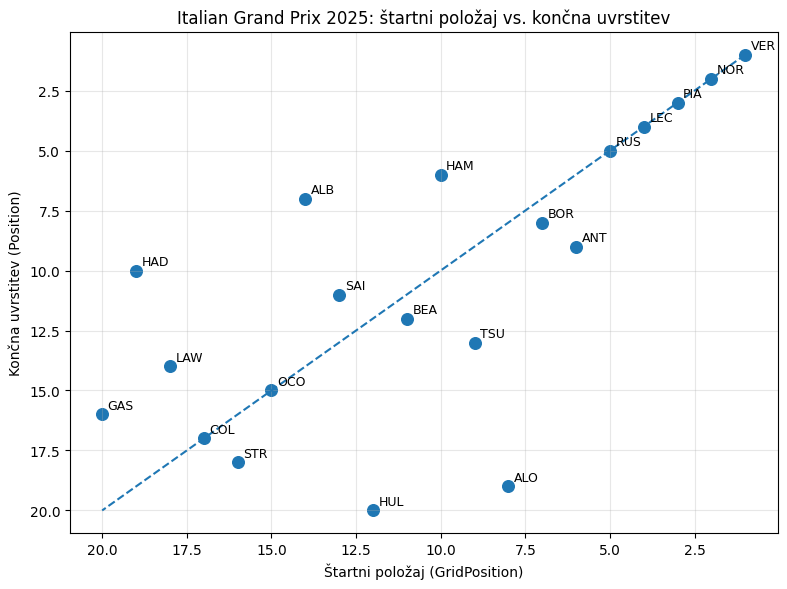

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(analysis_df["GridPosition"], analysis_df["Position"], s=70)

for _, row in analysis_df.iterrows():
    ax.annotate(row["Abbreviation"], (row["GridPosition"], row["Position"]),
                xytext=(4, 4), textcoords="offset points", fontsize=9)

# referenčna diagonala: finish = grid
x = np.arange(1, int(max(analysis_df["GridPosition"].max(), analysis_df["Position"].max())) + 1)
ax.plot(x, x, linestyle="--")

ax.set_title(f"{race.event['EventName']} {YEAR}: štartni položaj vs. končna uvrstitev")
ax.set_xlabel("Štartni položaj (GridPosition)")
ax.set_ylabel("Končna uvrstitev (Position)")
ax.invert_xaxis()
ax.invert_yaxis()   
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretacija za 1. točko

Ker je rho okoli 0.7 je  močna povezava med štartnim položajem in končno uverstutvijo.


Ker lahko odstopi umetno "pokvarijo" povezavo, spodaj naredimo še clean finish varianto.

In [52]:
# Približen filter za dirkače, ki so bili klasificirani / niso očiten DNF
clean_df = analysis_df.copy()
if "Status" in clean_df.columns:
    clean_df = clean_df[~clean_df["Status"].fillna("").str.contains("Accident|Collision|Engine|Gearbox|Hydraulics|DNF|Retired", case=False, regex=True)]

if len(clean_df) >= 5:
    s2, p2 = spearmanr(clean_df["GridPosition"], clean_df["Position"])
    print(f"Spearman (brez očitnih DNF/retirements): rho = {s2:.3f}, p = {p2:.4g}")
else:
    print("Premalo voznikov po filtru za clean-finish analizo.")

Spearman (brez očitnih DNF/retirements): rho = 0.788, p = 6.225e-05


## Sezonska analiza: ali je korelacija stabilna skozi več dirk?

Spodnja celica pregleda vse glavne dirke v sezoni in za vsako izračuna korelacijo.

In [53]:

def grid_vs_finish_for_event(year, round_number):
    session = fastf1.get_session(year, round_number, "R")
    session.load()
    res = session.results.copy()

    needed = [c for c in ["Abbreviation", "GridPosition", "Position", "Status"] if c in res.columns]
    df = res[needed].copy()
    df["GridPosition"] = pd.to_numeric(df["GridPosition"], errors="coerce")
    df["Position"] = pd.to_numeric(df["Position"], errors="coerce")
    df = df.dropna(subset=["GridPosition", "Position"])
    df = df[df["GridPosition"] > 0]

    if len(df) < 5:
        return None

    rho, p = spearmanr(df["GridPosition"], df["Position"])
    return {
        "Round": round_number,
        "Event": session.event["EventName"],
        "Spearman": rho,
        "PValue": p,
        "N": len(df)
    }

season_rows = []
schedule = fastf1.get_event_schedule(YEAR)

# poskusi pobrati samo 'conventional' dirke
for _, ev in schedule.iterrows():
    if "RoundNumber" not in ev or pd.isna(ev["RoundNumber"]):
        continue
    rnd = int(ev["RoundNumber"])
    try:
        row = grid_vs_finish_for_event(YEAR, rnd)
        if row is not None:
            season_rows.append(row)
    except Exception as e:
        print(f"Skipping round {rnd}: {e}")

season_corr = pd.DataFrame(season_rows)
season_corr.head()

Skipping round 0: Cannot get testing event by round number!


,Round,Event,Spearman,PValue,N
0,1,Australian Grand Prix,0.488722,2.877203e-02,20
1,2,Chinese Grand Prix,0.442105,5.096470e-02,20
2,3,Japanese Grand Prix,0.963910,8.653587e-12,20
3,4,Bahrain Grand Prix,0.715789,3.869133e-04,20
4,5,Saudi Arabian Grand Prix,0.732331,2.412164e-04,20


,Round,Event,Spearman,PValue,N
0,1,Australian Grand Prix,0.488722,2.877203e-02,20
1,2,Chinese Grand Prix,0.442105,5.096470e-02,20
2,3,Japanese Grand Prix,0.963910,8.653587e-12,20
3,4,Bahrain Grand Prix,0.715789,3.869133e-04,20
4,5,Saudi Arabian Grand Prix,0.732331,2.412164e-04,20
5,6,Miami Grand Prix,0.852632,1.800602e-06,20
6,7,Emilia Romagna Grand Prix,0.697744,6.253882e-04,20
7,8,Monaco Grand Prix,0.738346,2.014294e-04,20
8,9,Spanish Grand Prix,0.608772,5.671633e-03,19
9,10,Canadian Grand Prix,0.687218,8.149369e-04,20


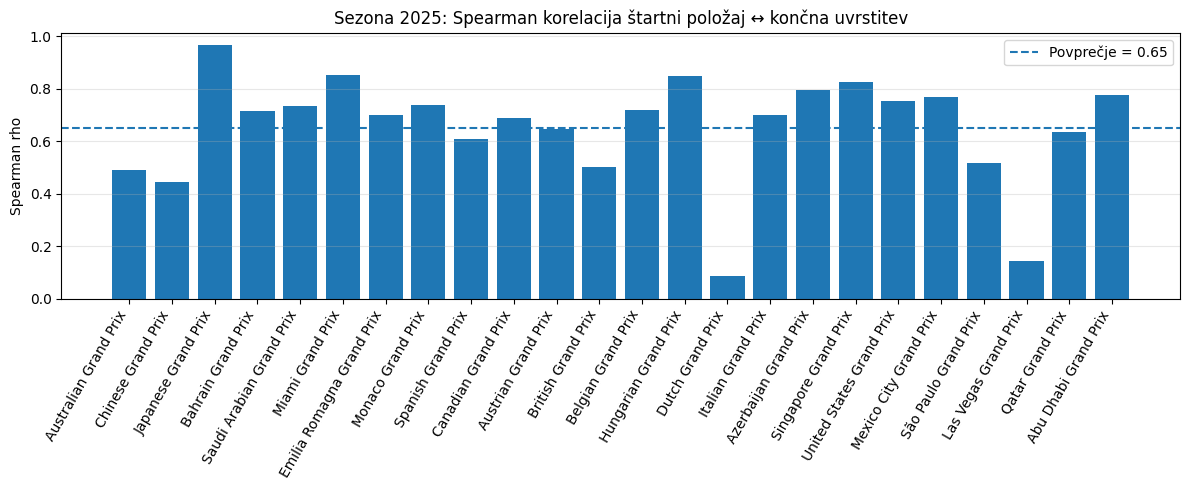

Povprečna sezonska Spearman korelacija: 0.651


In [54]:
if not season_corr.empty:
    display(season_corr.sort_values("Round"))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(season_corr["Event"], season_corr["Spearman"])
    ax.axhline(season_corr["Spearman"].mean(), linestyle="--",
               label=f"Povprečje = {season_corr['Spearman'].mean():.2f}")
    ax.set_title(f"Sezona {YEAR}: Spearman korelacija štartni položaj ↔ končna uvrstitev")
    ax.set_ylabel("Spearman rho")
    ax.set_xticklabels(season_corr["Event"], rotation=60, ha="right")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Povprečna sezonska Spearman korelacija: {season_corr['Spearman'].mean():.3f}")


### 2) Kaj je pomembnejše: hitrost na ravninah ali učinkovitost v ovinkih?

Za to zgradimo dve metriki iz dirke:

### A. Hitrost na ravninah
Uporabimo SpeedST iz race laps.  
Za vsakega voznika vzamemo:
- median SpeedST čez njegove reprezentativne kroge.

### B. Učinkovitost v ovinkih
Uporabimo telemetrijo in circuit_info.corners.

Postopek:
1. za vsakega voznika vzamemo njegov najhitrejši čist dirkalni krog,
2. telemetrijo preslikamo na razdaljo,
3. za vsak ovinek vzamemo hitrost v oknu okoli ovinka in izračunamo hitrost v ovinku,
4. iz vseh ovinkov vzamemo povprečje.

Nato primerjamo, katera metrika je bolj povezana z:
- končno uvrstitvijo
- race pace 



In [55]:

race_laps = race.laps.copy()


quick_laps = race_laps.pick_quicklaps().copy()


quick_laps[["Driver", "LapNumber", "LapTime", "SpeedST"]].head()

,Driver,LapNumber,LapTime,SpeedST
1,VER,2.0,0 days 00:01:24.859000,309.0
2,VER,3.0,0 days 00:01:23.512000,350.0
3,VER,4.0,0 days 00:01:23.262000,352.0
4,VER,5.0,0 days 00:01:23.588000,317.0
5,VER,6.0,0 days 00:01:23.576000,320.0


In [56]:
# Metrika 1: mediana SpeedST po quick laps
straight_metric = (
    quick_laps.groupby("Driver")["SpeedST"]
    .median()
    .rename("StraightSpeed")
    .reset_index()
)

# Metrika 2: mediana časa kroga po quick laps
pace_metric = (
    quick_laps.groupby("Driver")["LapTime"]
    .median()
    .rename("MedianRacePace")
    .reset_index()
)

straight_metric.head(), pace_metric.head()

(  Driver  StraightSpeed
 0    ALB          335.0
 1    ALO          336.0
 2    ANT          329.0
 3    BEA          323.0
 4    BOR          325.0,
   Driver         MedianRacePace
 0    ALB 0 days 00:01:23.723000
 1    ALO 0 days 00:01:24.472500
 2    ANT 0 days 00:01:23.593000
 3    BEA 0 days 00:01:23.334000
 4    BOR 0 days 00:01:23.509000)

In [57]:

circuit_info = race.get_circuit_info()
corners = circuit_info.corners.copy()


display(corners.head())

,X,Y,Number,Letter,Angle,Distance
0,-569.580505,8153.724609,1,,153.787332,878.753926
1,-146.754578,8474.981445,2,,-13.835843,940.331876
2,611.600159,13310.620117,3,,133.028518,1463.017000
3,6808.655273,14630.753906,4,,-54.042256,2095.220412
4,7130.872070,15023.123047,5,,121.752858,2151.692087


In [58]:
def corner_eff(session, driver, window_m=80):

    laps = session.laps.pick_driver(driver).pick_quicklaps()
    if laps.empty:
        return np.nan

    fastest = laps.pick_fastest()
    if fastest is None or pd.isna(fastest["LapTime"]):
        return np.nan

    tel = fastest.get_car_data().add_distance().copy()
    if tel.empty or "Distance" not in tel.columns or "Speed" not in tel.columns:
        return np.nan

    corner_speeds = []
    for _, c in corners.iterrows():
        d = c.get("Distance", np.nan)
        if pd.isna(d):
            continue

        chunk = tel[(tel["Distance"] >= d - window_m) & (tel["Distance"] <= d + window_m)]
        if len(chunk) < 3:
            continue

        # apex proxy: minimal speed v območju ovinka
        apex_speed = chunk["Speed"].min()
        corner_speeds.append(apex_speed)

    if len(corner_speeds) == 0:
        return np.nan

    return float(np.mean(corner_speeds))

In [59]:
corner_rows = []
for drv in race.drivers:
    
        drv_code = race.get_driver(drv)["Abbreviation"]


        value = corner_eff(race, drv_code, window_m=80)
        corner_rows.append({"Driver": drv_code, "CornerEfficiency": value})


corner_metric = pd.DataFrame(corner_rows).dropna()
corner_metric.head()

,Driver,CornerEfficiency
0,VER,167.909091
1,NOR,169.000000
2,PIA,169.545455
3,LEC,163.454545
4,RUS,165.090909


In [60]:
# Združi vse metrike
results_map = analysis_df[["Abbreviation", "Position", "GridPosition"]].copy()
results_map = results_map.rename(columns={"Abbreviation": "Driver", "Position": "FinishPosition"})

pace_metric["MedianRacePaceSec"] = pace_metric["MedianRacePace"].dt.total_seconds()
pace_metric = pace_metric.drop(columns=["MedianRacePace"])

merged = (
    results_map
    .merge(straight_metric, on="Driver", how="left")
    .merge(corner_metric, on="Driver", how="left")
    .merge(pace_metric, on="Driver", how="left")
)

merged = merged.dropna(subset=["FinishPosition", "StraightSpeed", "CornerEfficiency", "MedianRacePaceSec"])
merged = merged.sort_values("FinishPosition")
merged

,Driver,FinishPosition,GridPosition,StraightSpeed,CornerEfficiency,MedianRacePaceSec
0,VER,1.0,1.0,322.5,167.909091,82.8735
1,NOR,2.0,2.0,324.0,169.000000,82.9660
2,PIA,3.0,3.0,326.0,169.545455,82.9380
3,LEC,4.0,4.0,324.5,163.454545,83.1020
4,RUS,5.0,5.0,329.0,165.090909,83.1395
5,HAM,6.0,10.0,326.5,162.454545,83.4290
6,ALB,7.0,14.0,335.0,164.272727,83.7230
7,BOR,8.0,7.0,325.0,158.272727,83.5090
8,ANT,9.0,6.0,329.0,164.454545,83.5930
9,HAD,10.0,19.0,331.0,163.272727,83.8010


In [61]:
# Korelacija z rezultatom dirke

def corr(df, xcol, ycol):
    s, sp = spearmanr(df[xcol], df[ycol])
    p, pp = pearsonr(df[xcol], df[ycol])
    return {
        "Metric": xcol,
        "Target": ycol,
        "Spearman": s,
        "Spearman_p": sp,
        "Pearson": p,
        "Pearson_p": pp
    }

reports = []
for metric in ["StraightSpeed", "CornerEfficiency"]:
    reports.append(corr(merged, metric, "FinishPosition"))
    reports.append(corr(merged, metric, "MedianRacePaceSec"))

corr_df = pd.DataFrame(reports)
corr_df

,Metric,Target,Spearman,Spearman_p,Pearson,Pearson_p
0,StraightSpeed,FinishPosition,0.155949,0.523776,0.191263,0.432816
1,StraightSpeed,MedianRacePaceSec,0.169165,0.488732,0.253253,0.295497
2,CornerEfficiency,FinishPosition,-0.515789,0.023792,-0.562763,0.012125
3,CornerEfficiency,MedianRacePaceSec,-0.512281,0.024931,-0.563899,0.011915


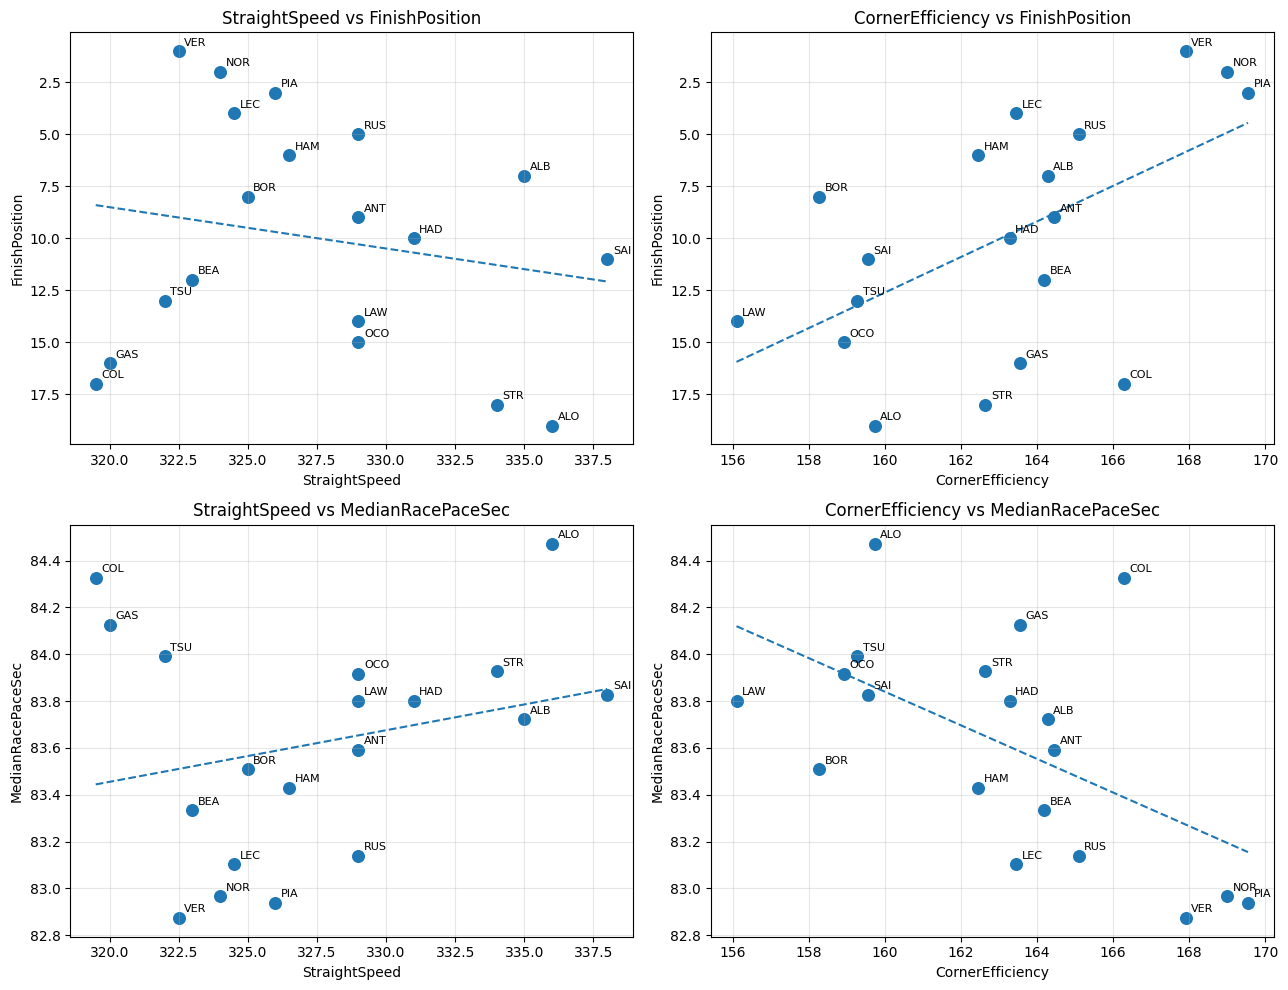

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

pairs = [
    ("StraightSpeed", "FinishPosition"),
    ("CornerEfficiency", "FinishPosition"),
    ("StraightSpeed", "MedianRacePaceSec"),
    ("CornerEfficiency", "MedianRacePaceSec"),
]

for ax, (xcol, ycol) in zip(axes.flat, pairs):
    ax.scatter(merged[xcol], merged[ycol], s=70)
    for _, row in merged.iterrows():
        ax.annotate(row["Driver"], (row[xcol], row[ycol]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{xcol} vs {ycol}")
    ax.grid(True, alpha=0.3)

    # trend line
    z = np.polyfit(merged[xcol], merged[ycol], 1)
    p = np.poly1d(z)
    xs = np.linspace(merged[xcol].min(), merged[xcol].max(), 100)
    ax.plot(xs, p(xs), linestyle="--")


axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()

plt.tight_layout()
plt.show()

In [63]:

summary = corr_df.copy()
summary["AbsSpearman"] = summary["Spearman"].abs()
summary = summary.sort_values(["Target", "AbsSpearman"], ascending=[True, False])

display(summary)

for target in ["FinishPosition", "MedianRacePaceSec"]:
    sub = summary[summary["Target"] == target].sort_values("AbsSpearman", ascending=False)
    best = sub.iloc[0]
    print(f"Za target = {target} je močnejši signal: {best['Metric']} "
          f"(Spearman = {best['Spearman']:.3f}, Pearson = {best['Pearson']:.3f})")

,Metric,Target,Spearman,Spearman_p,Pearson,Pearson_p,AbsSpearman
2,CornerEfficiency,FinishPosition,-0.515789,0.023792,-0.562763,0.012125,0.515789
0,StraightSpeed,FinishPosition,0.155949,0.523776,0.191263,0.432816,0.155949
3,CornerEfficiency,MedianRacePaceSec,-0.512281,0.024931,-0.563899,0.011915,0.512281
1,StraightSpeed,MedianRacePaceSec,0.169165,0.488732,0.253253,0.295497,0.169165


Za target = FinishPosition je močnejši signal: CornerEfficiency (Spearman = -0.516, Pearson = -0.563)
Za target = MedianRacePaceSec je močnejši signal: CornerEfficiency (Spearman = -0.512, Pearson = -0.564)


## Končni rezultati

### Vprašanje 1

Na podlagi rezultatov vidimo, da je Spearmanova korelacija med štartnim položajem in končno uvrstitvijo približno 0.70, kar pomeni dokaj močno povezavo.
To pomeni, da so vozniki, ki so dobro nastopili v kvalifikacijah (štartali spredaj), v večini primerov tudi končali dirko na višjih mestih.
Zato lahko rečemo, da so kvalifikacije na tej dirki pomemben za končni rezultat.

### Vprašanje 2
Iz analize vidimo, da ima hitrost v kotih precej močnejšo povezavo z rezultatom kot hitrost v ravninah.
To pomeni, da so na tej progi bolj pomembni ovinki kot pa hitrost na ravninah.
Vozniki, ki so bili hitrejši v ovinkih, so imeli boljši tempo in tudi boljše končne rezultate.
